# Stable Diffusion

### Waifu Diffusion Huggingface
https://huggingface.co/hakurei/waifu-diffusion

### Prompts guide
https://www.reddit.com/r/WaifuDiffusion/comments/xudcdp/prompts_guide_by_cdcruz/

In [2]:
try:
    import diffusers
except:
    !pip install -q transformers==4.25.1
    !pip install -q accelerate==0.15.0
    !pip install -q diffusers==0.11.1
    import diffusers

import os
import time

import torch
import matplotlib.pyplot as plt
import numpy as np

if torch.backends.mps.is_available():
    device_name = torch.device("mps")
if torch.cuda.is_available():
    device_name = torch.device("cuda")
else:
    device_name = torch.device("cpu")

print("Using {}.".format(device_name))

Using cuda.


In [3]:
# Load (text to image) diffuser pipeline.
def load_pipeline(model_dir, scheduler = None, device_name = torch.device("cpu")):
    pipe = diffusers.StableDiffusionPipeline.from_pretrained(model_dir, torch_dtype = torch.float32)

    if scheduler is None or scheduler in ["EulerAncestralDiscreteScheduler", "EADS"]:
        pipe.scheduler = diffusers.EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
    elif scheduler in ["EulerDiscreteScheduler", "EDS"]:
        pipe.scheduler = diffusers.EulerDiscreteScheduler.from_config(pipe.scheduler.config)
    elif scheduler in ["DPMSolverMultistepScheduler", "DPMSMS"]:
        pipe.scheduler = diffusers.DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

    pipe.safety_checker = lambda images, **kwargs: [images, [False] * len(images)]
    pipe = pipe.to(device_name)
    return pipe

# Load image to image diffuser pipeline.
def load_img2img_pipeline(model_dir, device_name):
    pipe = diffusers.StableDiffusionImg2ImgPipeline.from_pretrained(model_dir, torch_dtype = torch.float16)
    pipe.scheduler = diffusers.EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
    pipe.safety_checker = lambda images, **kwargs: [images, [False] * len(images)]
    pipe = pipe.to(device_name)
    return pipe

In [4]:
# Run diffuser pipeline.
def run_pipe(pipe, prompt, negative_prompt = None, steps = 60, 
             width = 512, height = 704, scale = 8.0, seed = 123, n_images = 1):
    if width % 8 != 0:
        print("Image width must be multiples of 8... adjusting!")
        width = int(width / 8) * 8
    if height % 8 != 0:
        print("Image width must be multiples of 8... adjusting!")
        height = int(height / 8) * 8

    gen = torch.Generator(device = device_name).manual_seed(seed)
    image_list = []
    with torch.autocast("cuda"): 
        for i in range(n_images): 
            image = pipe(prompt, height = height, width = width, 
                         num_inference_steps = steps, guidance_scale = scale,
                         negative_prompt = negative_prompt, generator = gen)
            image_list = image_list + image.images

    return image_list

In [5]:
# Plot pipeline outputs.
def plot_images(images, labels = None):
    N = len(images)
    n_cols = 5
    n_rows = int(np.ceil(N / n_cols))

    plt.figure(figsize = (20, 5 * n_rows))
    for i in range(len(images)):
        plt.subplot(n_rows, n_cols, i + 1)
        if labels is not None:
            plt.title(labels[i])
        plt.imshow(np.array(images[i]))
        plt.axis(False)
    plt.show()

In [ ]:
scheduler = "EADS"
#model_dir = "hakurei/waifu-diffusion"

model_dir = "WarriorMama777/OrangeMixs/AbyssOrangeMix2"

if model_dir == "WarriorMama777/OrangeMixs/AbyssOrangeMix2":
    !mkdir -p "AbyssOrangeMix2"
    # !wget "" -O AbyssOrangeMix2/
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/raw/main/model_index.json" -O AbyssOrangeMix2/model_index.json 

    !mkdir -p "AbyssOrangeMix2/feature_extractor"
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/raw/main/Models/AbyssOrangeMix2/Diffusers/feature_extractor/preprocessor_config.json" -O AbyssOrangeMix2/feature_extractor/preprocessor_config.json

    !mkdir -p "AbyssOrangeMix2/safety_checker"
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/raw/main/Models/AbyssOrangeMix2/Diffusers/safety_checker/config.json" -O AbyssOrangeMix2/safety_checker/config.json
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/resolve/main/Models/AbyssOrangeMix2/Diffusers/safety_checker/pytorch_model.bin" -O AbyssOrangeMix2/safety_checker/pytorch_model.bin

    !mkdir -p "AbyssOrangeMix2/scheduler"
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/raw/main/Models/AbyssOrangeMix2/Diffusers/scheduler/scheduler_config.json" -O AbyssOrangeMix2/scheduler/scheduler_config.json

    !mkdir -p "AbyssOrangeMix2/text_encoder"
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/raw/main/Models/AbyssOrangeMix2/Diffusers/text_encoder/config.json" -O AbyssOrangeMix2/text_encoder/config.json
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/resolve/main/Models/AbyssOrangeMix2/Diffusers/text_encoder/pytorch_model.bin" -O AbyssOrangeMix2/text_encoder/pytorch_model.bin

    !mkdir -p "AbyssOrangeMix2/tokenizer"
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/raw/main/Models/AbyssOrangeMix2/Diffusers/tokenizer/merges.txt" -O AbyssOrangeMix2/tokenizer/merges.txt
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/raw/main/Models/AbyssOrangeMix2/Diffusers/tokenizer/special_tokens_map.json" -O AbyssOrangeMix2/tokenizer/special_tokens_map.json
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/raw/main/Models/AbyssOrangeMix2/Diffusers/tokenizer/tokenizer_config.json" -O AbyssOrangeMix2/tokenizer/tokenizer_config.json
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/raw/main/Models/AbyssOrangeMix2/Diffusers/tokenizer/vocab.json" -O AbyssOrangeMix2/tokenizer/vocab.json

    !mkdir -p "AbyssOrangeMix2/unet"
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/raw/main/Models/AbyssOrangeMix2/Diffusers/unet/config.json" -O AbyssOrangeMix2/unet/config.json
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/resolve/main/Models/AbyssOrangeMix2/Diffusers/unet/diffusion_pytorch_model.bin" -O AbyssOrangeMix2/unet/diffusion_pytorch_model.bin

    !mkdir -p "AbyssOrangeMix2/vae"
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/raw/main/Models/AbyssOrangeMix2/Diffusers/vae/config.json" -O AbyssOrangeMix2/vae/config.json
    !wget "https://huggingface.co/WarriorMama777/OrangeMixs/resolve/main/Models/AbyssOrangeMix2/Diffusers/vae/diffusion_pytorch_model.bin"  -O AbyssOrangeMix2/vae/diffusion_pytorch_model.bin

    model_dir = "AbyssOrangeMix2"
    scheduler = "DPMSMS"

In [26]:
# Text to image pipe line.
pipe = load_pipeline(model_dir, scheduler, device_name)

# Image to image pipeline.
#img2img_pipe = load_img2img_pipeline(model_dir, device_name)

In [ ]:
# Negative prompt embeddings.
# https://www.reddit.com/r/StableDiffusion/comments/xcxb26/figured_out_how_to_load_embeddingspt_in_diffusers/
# Gives size error...

#!wget "https://github.com/natsunoyuki/stable_diffusion/raw/main/bad-image-v2-39000.pt" -O "bad-image-v2-39000.pt"

In [ ]:
#loaded_embeds = torch.load("bad-image-v2-39000.pt", map_location = device_name)

#print(loaded_embeds.keys())
#string_to_token = loaded_embeds['string_to_token']
#string_to_param = loaded_embeds['string_to_param']
#token = list(string_to_token.keys())[0]
#print(f'got key {token}')

In [ ]:
#pipe.text_encoder.get_input_embeddings().weight.shape

In [ ]:
#embeds = string_to_param[token]
#dtype = pipe.text_encoder.get_input_embeddings().weight.dtype
#embeds.to(dtype)
#token = '<my-face>'
#num_added_tokens = pipe.tokenizer.add_tokens(token)

#if num_added_tokens == 0:
#    print(f'tokenizer already contains the token {token}')

In [ ]:
#pipe.text_encoder.resize_token_embeddings(len(pipe.tokenizer))
#token_id = pipe.tokenizer.convert_tokens_to_ids(token)
#pipe.text_encoder.get_input_embeddings().weight.data[token_id] = embeds

## Anime Trial 0

In [76]:
# For use with EADS scheduler.
#prompt_0 = """((masterpiece)),(best quality),(8k),(beautiful detailed face),photorealistic,(perfect anatomy),(1girl),solo,long hair,
#(white bikini),(large breasts),spreading legs,(pleasured expression),slim,thin waist,(mature woman),perfect face,(cleavage)"""

#negative_prompt = """(worst quality),(low quality),medium quality,deleted,lowres,cartoon,3d,comic,(bad anatomy),bad hands,text,error,
#(deformed),(blurry),missing fingers,extra digit,fewer digits,(disfigured),(poorly drawn face),mutation,mutated,extra limb,ugly,
#poorly drawn hands,two heads,child,kid,gross,mutilated,disgusting,horrible,scary,evil,old,conjoined"""


# https://www.reddit.com/r/WaifuDiffusion/comments/10n3vki/woman_in_black/
# Original prompt:
#prompt_0 = """woman,(hands behind back: 1.9),masterpiece,best quality,high quality,absurdres,extreme details,realistic lighting,beautiful detailed glow,
#full body,black hair,medium breasts,highly detailed,best quality,uhd,8k,translucid dress,thorn clothes,red eyes,malificent smile,
#marble pillars in background, classic party room in background, chandelier in background,hoop earring"""

# Original negative prompt:
#negative_prompt = """(sketch by bad-artist),(bad_prompt_version2:0.8),bad hands,(worst quality,low quality:1.3),(depth of field,blurry:1.2),
#(greyscale,monochrome:1.1),3D face,nose,cropped,lowres,text,jpeg artifacts,signature,watermark,username,blurry,artist name,trademark,watermark,
#title,(tan,muscular,loli,petite,child,infant,toddlers,chibi,sd character:1.1),multiple view,Reference sheet,((bare shoulders)),(((ugly))),
#(((unclear eyes))),multiple halos"""

# Steps: 30, Sampler: DPM++ SDE Karras, CFG scale: 7, Seed: 4116057658, Size: 1024x1536, Model hash: 0fc198c490
# Model: abyssorangemix2NSFW, Denoising strength: 0.6, Clip skip: 2, Mask blur: 4


# https://www.reddit.com/r/WaifuDiffusion/comments/10m68dw/no_inpainting_at_all_just_pure_txt2img/
# Original prompt:
#prompt_0 = """masterpiece,masterpiece portrait,best quality,extremely detailed,watercolor,depth of field,realistic lighting,
#1girl,solo,Instagram model,character focus,bunny head dress,thigh boots,nipples,nude,vagina,hips out,white gloves"""

# Original negative prompt:
#negative_prompt = """(bad-image-v2-39000:0.8),watermark,text,error,blurry,jpeg artifacts,cropped,normal quality,jpeg artifacts,signature,watermark,
#username,artist name,(worst quality:1.3),(low quality:1.3),(loli:1.1),(loli face:1.1),thick lips,(jumbled fingers),(((kid))),(((child like)))"""

# Steps: 150, Sampler: DPM++ SDE Karras, CFG scale: 12, Seed: 9, Size: 512x1024, Model hash: a87fd7da
# Used embeddings: bad-image-v2-39000 [b03e]

#prompt_0 = """masterpiece,masterpiece portrait,best quality,extremely detailed,photo,photorealistic,depth of field,realistic lighting,
#1girl,solo,Instagram model,character focus,thigh boots,nipples,nude,vagina,hips out"""

prompt_0 = """masterpiece,masterpiece portrait,best quality,extremely detailed,photo,photorealistic,depth of field,realistic lighting,
1girl,solo,Instagram model,character focus,white stockings,(large breasts),(white lingerie),(sexy expression)"""

negative_prompt = """watermark,text,error,blurry,jpeg artifacts,cropped,normal quality,jpeg artifacts,signature,
username,artist name,(worst quality:1.3),(low quality:1.3),(loli:1.1),(loli face:1.1),thick lips,((jumbled fingers)),
((missing fingers)),((extra fingers)),(poorly drawn hands),(((kid))),(((child like)))"""

In [77]:
if type(pipe.scheduler) == diffusers.EulerAncestralDiscreteScheduler:
    print("EulerAncestralDiscreteScheduler")
    images_0 = run_pipe(pipe, prompt_0, negative_prompt, steps = 60, width = 512, height = 704, scale = 8.0, seed = 123, n_images = 1)
elif type(pipe.scheduler) == diffusers.DPMSolverMultistepScheduler:
    print("DPMSolverMultistepScheduler")
    images_0 = run_pipe(pipe, prompt_0, negative_prompt, steps = 150, width = 512, height = 832, scale = 12, seed = 9, n_images = 1)

DPMSolverMultistepScheduler


  0%|          | 0/150 [00:00<?, ?it/s]

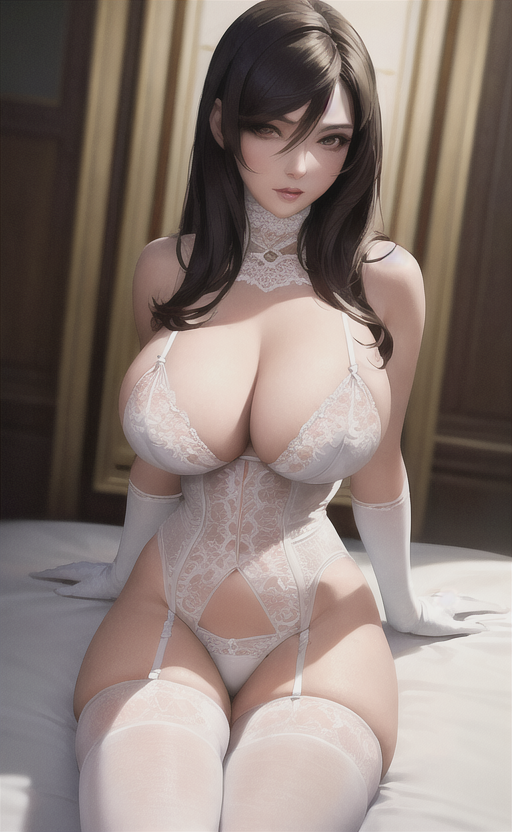

In [78]:
[display(i) for i in images_0];

## Anime Trial 1

In [88]:
if type(pipe.scheduler) == diffusers.EulerAncestralDiscreteScheduler:
    print("EulerAncestralDiscreteScheduler")
    images_1 = run_pipe(pipe, prompt_0, negative_prompt, steps = 64, width = 512, height = 704, scale = 8.0, seed = 1029384756, n_images = 1)
elif type(pipe.scheduler) == diffusers.DPMSolverMultistepScheduler:
    print("DPMSolverMultistepScheduler")
    images_1 = run_pipe(pipe, prompt_0, negative_prompt, steps = 150, width = 512, height = 832, scale = 12, seed = 1029384756, n_images = 1)

DPMSolverMultistepScheduler


  0%|          | 0/150 [00:00<?, ?it/s]

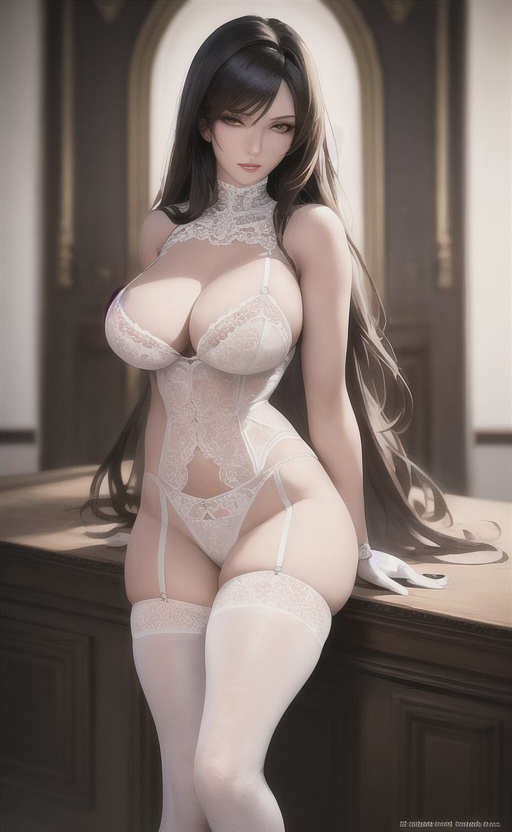

In [89]:
[display(i) for i in images_1];

### Anime Trial 1 - Steps

In [ ]:
#steps = list(range(51, 70 + 1, 1))
#images_1_steps = []
#for s in steps:
#    images_1_steps += run_pipe(pipe, prompt_0, negative_prompt, steps = s, width = 512, height = 704, scale = 8.0, seed = 1029384756, n_images = 1)

In [ ]:
#plot_images(images_1_steps, steps)

### Anime Trial 1 - Seeds

In [ ]:
np.random.seed(123456789)
seeds = list(int(s) for s in np.random.randint(1e8, size = 20))

images_1_seeds = []
if type(pipe.scheduler) == diffusers.EulerAncestralDiscreteScheduler:
    print("EulerAncestralDiscreteScheduler")
    for s in seeds:
        images_1_seeds += run_pipe(pipe, prompt_0, negative_prompt, steps = 30, width = 512, height = 704, scale = 7.5, seed = s, n_images = 1)
elif type(pipe.scheduler) == diffusers.DPMSolverMultistepScheduler:
    print("DPMSolverMultistepScheduler")
    for s in seeds:
        images_1_seeds += run_pipe(pipe, prompt_0, negative_prompt, steps = 150, width = 512, height = 832, scale = 12, seed = s, n_images = 1)

In [ ]:
plot_images(images_1_seeds, seeds)

## Anime Trial 2

In [ ]:
#images_2 = run_pipe(pipe, prompt_0, negative_prompt, steps = 63, width = 600, height = 800, scale = 8.0, seed = 1029384756, n_images = 1)

In [ ]:
#[display(i) for i in images_2];

## Anime Trial 3

In [ ]:
# Prompt and negative prompt.

#prompt_3 = """((masterpiece)),(best quality),(8k),(beautiful detailed face),photorealistic,
#(perfect anatomy),(1girl),solo,long hair,(white bikini),(large breasts),covered nipples,seaside,
#(sexy expression),slim,thin waist,(mature woman),perfect face,cleavage"""

# Good seeds to try?
# 58, 550, 565

In [ ]:
#seeds = list(range(30, 60))    

#images_3_seeds = []
#for s in seeds:
#    images_3_seeds += run_pipe(pipe, prompt_3, negative_prompt, steps = 60, width = 600, height = 800, scale = 8.0, seed = s, n_images = 1)

In [ ]:
#plot_images(images_3_seeds, seeds)